### 1. Dataset loading and initial inspection

I load the APY.csv file containing district‑level agricultural statistics for India from 1997 onwards. The dataset has 345,336 rows and 8 columns, including identifiers (State, District, Crop, Crop_Year, Season) and numerical variables (Area, Production, Yield). This confirms that the data is large enough for supervised learning and that yield is already available as a continuous target variable.


Step 1 – Set up environment and load CSV


In [ ]:
# Imports and basic settings
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

# Load the dataset (update the path if needed)
file_path = "APY.csv"  # change if your filename is different
df = pd.read_csv(file_path)

In [ ]:
# Step 3: Quick overview
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())


Shape: (345336, 8)

Columns:
 Index(['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ',
       'Production', 'Yield'],
      dtype='object')

Data types:
 State          object
District       object
Crop           object
Crop_Year       int64
Season         object
Area          float64
Production    float64
Yield         float64
dtype: object

First 5 rows:


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75


The initial inspection shows:

- **Shape:** 345,336 rows × 8 columns, indicating a large tabular dataset suitable for machine learning.
- **Categorical features:** State, District, Crop, Season.
- **Temporal feature:** Crop_Year (integer).
- **Numerical features:** Area (hectares), Production (tonnes), Yield (tonnes per hectare).

These variables align with our research question: predicting crop yield from crop type, season, cultivated area and region over multiple years.


Step 2 – Basic cleaning and sanity checks

In [ ]:
# Step 2: Basic cleaning and sanity checks

# 2.1 Strip whitespace from column names
df.columns = df.columns.str.strip()

print("Columns after stripping whitespace:\n", df.columns)

# 2.2 Check basic info and missing values
print("\nDataFrame info:")
print(df.info())

print("\nMissing values per column:")
print(df.isna().sum())

# 2.3 Basic descriptive statistics for numerical columns
print("\nDescriptive statistics (numerical features):")
display(df[["Area", "Production", "Yield"]].describe())

# 2.4 Check unique counts for key categorical variables
for col in ["State", "District", "Crop", "Season", "Crop_Year"]:
    print(f"\n{col} - unique values:", df[col].nunique())


Columns after stripping whitespace:
 Index(['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area',
       'Production', 'Yield'],
      dtype='object')

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        345327 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  object 
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB
None

Missing values per column:
State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

Descriptive statistics (numerical 

,Area,Production,Yield
count,3.453360e+05,3.403880e+05,345336.000000
mean,1.167147e+04,9.584726e+05,79.423135
std,4.584079e+04,2.153068e+07,916.678396
min,4.000000e-03,0.000000e+00,0.000000
25%,7.400000e+01,8.700000e+01,0.550000
50%,5.320000e+02,7.170000e+02,1.000000
75%,4.112000e+03,7.182000e+03,2.470000
max,8.580100e+06,1.597800e+09,43958.330000



State - unique values: 37

District - unique values: 707

Crop - unique values: 55

Season - unique values: 6

Crop_Year - unique values: 24


### 2. Basic cleaning and initial sanity checks

After stripping trailing whitespace, the dataset contains 8 clean column names: State, District, Crop, Crop_Year, Season, Area, Production and Yield. There are 345,336 records, with complete values for State, District, Crop_Year, Season, Area and Yield, but 9 missing values in Crop and 4,948 missing values in Production.

The numerical summary shows that Area, Production and Yield span several orders of magnitude, with some extremely large maximum values (e.g. Area up to 8,580,100 hectares and Yield up to 43,958.33). This suggests the presence of outliers or data entry issues that will need to be investigated and possibly treated before model training.

The dataset covers 37 States/UTs, 707 Districts, 55 Crops, 6 Seasons and 24 distinct crop years, providing rich spatial and temporal variation for supervised learning at district level.


Step 3 – Simple EDA: distributions and outliers

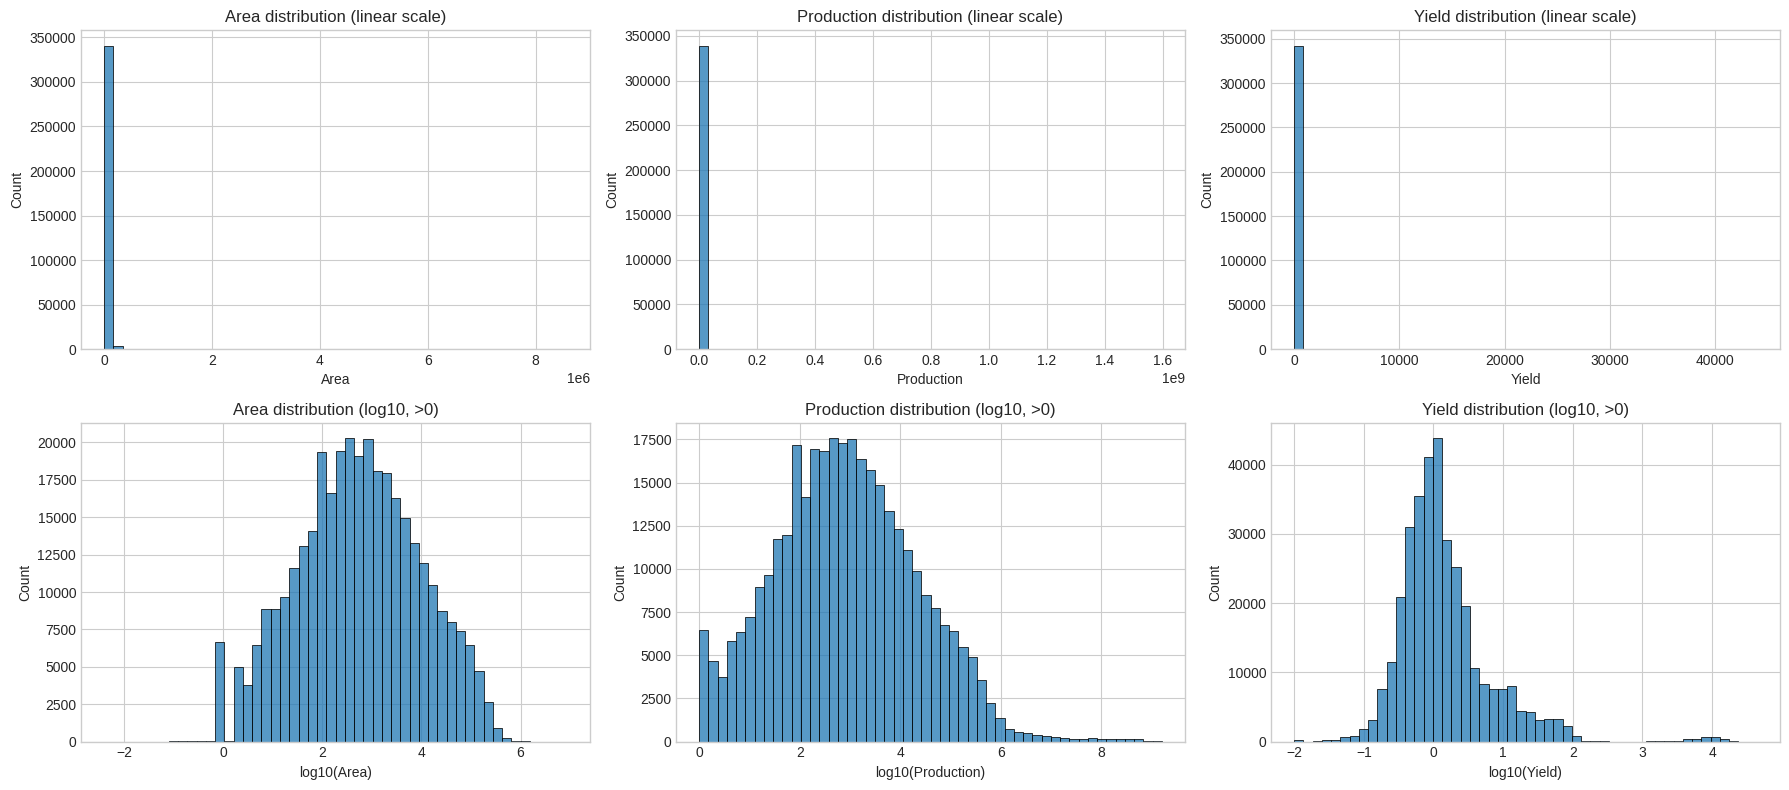

In [ ]:
# Step 3: Exploratory plots for numerical features

num_cols = ["Area", "Production", "Yield"]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram (linear scale)
    sns.histplot(df[col].dropna(), bins=50, ax=axes[0, i], kde=False)
    axes[0, i].set_title(f"{col} distribution (linear scale)")

    # Histogram (log10 scale, filter > 0)
    positive_vals = df[col][df[col] > 0]
    sns.histplot(np.log10(positive_vals), bins=50, ax=axes[1, i], kde=False)
    axes[1, i].set_title(f"{col} distribution (log10, >0)")
    axes[1, i].set_xlabel(f"log10({col})")

plt.tight_layout()
plt.show()


### 3. Exploratory analysis of numerical variables

The histograms on linear scale show that Area, Production and Yield are extremely right‑skewed, with most observations concentrated near zero and a long tail of very large values. This is expected for agricultural production data because districts and crops vary greatly in cultivated area and output.

After applying a log10 transformation (for positive values), the distributions of Area and Production become approximately bell‑shaped, while Yield shows a main cluster between about 10⁻¹ and 10¹ tonnes/ha and a very small number of extreme outliers at much higher values. These extreme yield values are likely due to aggregation issues or data entry errors and will be considered for filtering or robust modelling later.


Step 4 – cleaning target & basic filters

In [ ]:
# Step 4: Create a working copy and apply minimal cleaning

df_work = df.copy()

# 4.1 Drop rows with missing Crop (only 9 rows)
before = df_work.shape[0]
df_work = df_work.dropna(subset=["Crop"])
after = df_work.shape[0]
print("Dropped rows with missing Crop:", before - after)

# 4.2 Drop rows with non-positive Yield (cannot model zero/negative yield meaningfully)
before = df_work.shape[0]
df_work = df_work[df_work["Yield"] > 0]
after = df_work.shape[0]
print("Dropped rows with non-positive Yield:", before - after)

# 4.3 Inspect extreme yield values (top 0.1%)
threshold = df_work["Yield"].quantile(0.999)
print("0.1% upper quantile for Yield:", threshold)

print("\nTop 10 Yield values:")
print(df_work["Yield"].sort_values(ascending=False).head(10))


Dropped rows with missing Crop: 9
Dropped rows with non-positive Yield: 6091
0.1% upper quantile for Yield: 14398.372500000341

Top 10 Yield values:
24551     43958.33
333525    38800.00
258896    33133.61
24552     32957.75
3122      31578.95
24548     30093.33
3229      29772.00
24549     28789.47
24303     28334.16
24402     26270.83
Name: Yield, dtype: float64


In [ ]:
print(df.isna().sum())

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64


In [ ]:
print(df.describe)

<bound method NDFrame.describe of                              State  District      Crop  Crop_Year  \
0       Andaman and Nicobar Island  NICOBARS  Arecanut       2007   
1       Andaman and Nicobar Island  NICOBARS  Arecanut       2007   
2       Andaman and Nicobar Island  NICOBARS  Arecanut       2008   
3       Andaman and Nicobar Island  NICOBARS  Arecanut       2008   
4       Andaman and Nicobar Island  NICOBARS  Arecanut       2009   
...                            ...       ...       ...        ...   
345331                 West Bengal   PURULIA     Wheat       2015   
345332                 West Bengal   PURULIA     Wheat       2016   
345333                 West Bengal   PURULIA     Wheat       2017   
345334                 West Bengal   PURULIA     Wheat       2018   
345335                 West Bengal   PURULIA     Wheat       2019   

             Season    Area  Production  Yield  
0       Kharif       2439.6      3415.0   1.40  
1       Rabi         1626.4      2277.0

### 4. Minimal cleaning of target and key fields

I created a working copy of the dataset and first removed 9 rows with missing `Crop`, since this is a key categorical feature for modelling. I then excluded 6,091 records with non‑positive `Yield`, because zero or negative yield is not meaningful for a supervised regression task where the target represents tonnes per hectare.

To understand the scale of extreme values, I inspected the upper tail of the yield distribution. The 0.1% upper quantile of `Yield` is about 14,398 t/ha, while the maximum observed values range from roughly 26,000 to 44,000 t/ha. These values are far above realistic agronomic yields and are likely due to reporting or aggregation artefacts, so I will later consider filtering or capping them when constructing the final training set.


Step 5 – define an outlier rule and build modelling dataset

In [ ]:
# Step 5: Define a yield outlier threshold and create modelling dataset

# For example, keep yields <= 200 (t/ha) – adjust if needed after inspection
yield_threshold = 200.0

before = df_work.shape[0]
df_model = df_work[df_work["Yield"] <= yield_threshold].copy()
after = df_model.shape[0]

print("Yield threshold:", yield_threshold)
print("Rows before:", before)
print("Rows after :", after)
print("Rows removed as extreme yield outliers:", before - after)

print("\nNew Yield summary:")
print(df_model["Yield"].describe())


Yield threshold: 200.0
Rows before: 339236
Rows after : 336311
Rows removed as extreme yield outliers: 2925

New Yield summary:
count    336311.000000
mean          4.574071
std          12.255412
min           0.010000
25%           0.570000
50%           1.020000
75%           2.440000
max         199.390000
Name: Yield, dtype: float64


### 5. Handling extreme yield outliers

To reduce the influence of implausible yield values, I filtered the working dataset to keep only records with `Yield` ≤ 200 t/ha. This removed 2,925 rows, leaving 336,311 observations in the modelling dataset (`df_model`), which is still more than sufficient for supervised learning.

After filtering, the yield distribution has a mean of about 4.57 t/ha and a maximum of 199.39 t/ha, with the interquartile range between 0.57 and 2.44 t/ha. These values are consistent with reported yields for major crops in India, suggesting that the remaining data are within a realistic agronomic range.


In [ ]:
print(df.isna().sum())

State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64



***

### Step 6 – Decide how to treat missing `Production`

For **yield prediction**, the essential columns are: State, District, Crop, Season, Crop_Year, Area, Yield. `Production` is redundant because \( \text{Yield} = \frac{\text{Production}}{\text{Area}} \), and you already have Yield.

In [ ]:
# Step 6: Remove Production for modelling but keep original df for EDA if needed

print("Missing values in original df:")
print(df.isna().sum())

# For modelling we will use df_model without Production
model_cols = ["State", "District", "Crop", "Season", "Crop_Year", "Area", "Yield"]
df_model = df_model[model_cols].copy()

print("\nColumns used for modelling:")
print(df_model.columns)


Missing values in original df:
State            0
District         0
Crop             9
Crop_Year        0
Season           0
Area             0
Production    4948
Yield            0
dtype: int64

Columns used for modelling:
Index(['State', 'District', 'Crop', 'Season', 'Crop_Year', 'Area', 'Yield'], dtype='object')


Step 7 – Extra EDA and visualisation (before splitting)

7.1 Mean yield by season

Season
Autumn          1.459812
Rabi            2.243787
Kharif          2.329625
Summer          3.347550
Winter          6.013703
Whole Year     13.500904
Name: Yield, dtype: float64


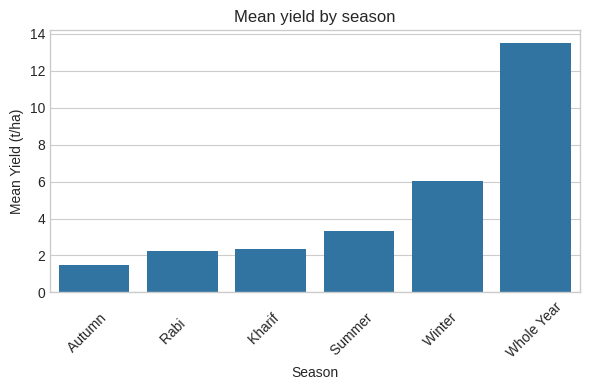

In [ ]:
season_yield = df_model.groupby("Season")["Yield"].mean().sort_values()
print(season_yield)

plt.figure(figsize=(6,4))
sns.barplot(x=season_yield.index, y=season_yield.values)
plt.ylabel("Mean Yield (t/ha)")
plt.title("Mean yield by season")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


7.2 Mean yield by crop (top 15)

Number of crops: 55

Top 15 crops by mean yield:
Crop
Sugarcane       56.073951
Coconut         35.063333
Banana          29.813469
Tapioca         18.946911
Potato          13.090923
Onion           12.390717
Jute             9.775411
Sweet potato     9.439853
Ginger           6.686928
Mesta            5.421103
Garlic           4.315774
Turmeric         3.568479
Bajra            2.660963
Tobacco          2.453714
Arecanut         2.416633
Name: Yield, dtype: float64


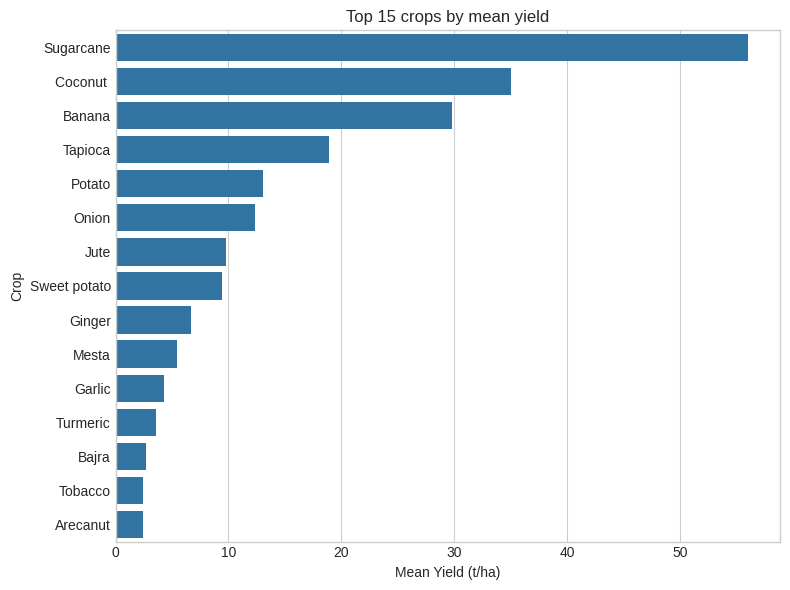

In [ ]:
crop_yield = df_model.groupby("Crop")["Yield"].mean().sort_values(ascending=False)

print("Number of crops:", crop_yield.shape[0])
print("\nTop 15 crops by mean yield:")
print(crop_yield.head(15))

plt.figure(figsize=(8,6))
sns.barplot(y=crop_yield.head(15).index, x=crop_yield.head(15).values)
plt.xlabel("Mean Yield (t/ha)")
plt.title("Top 15 crops by mean yield")
plt.tight_layout()
plt.show()


7.3 Mean yield over time

Crop_Year
1997    4.036223
1998    4.198422
1999    4.442074
2000    4.003579
2001    4.064499
2002    4.004104
2003    4.209971
2004    4.113654
2005    4.506213
2006    4.342340
2007    4.326473
2008    4.382745
2009    4.504462
2010    4.279817
2011    4.522829
2012    4.595316
2013    4.894376
2014    4.950129
2015    4.913503
2016    5.009507
2017    5.268640
2018    5.268492
2019    5.226036
2020    4.140439
Name: Yield, dtype: float64


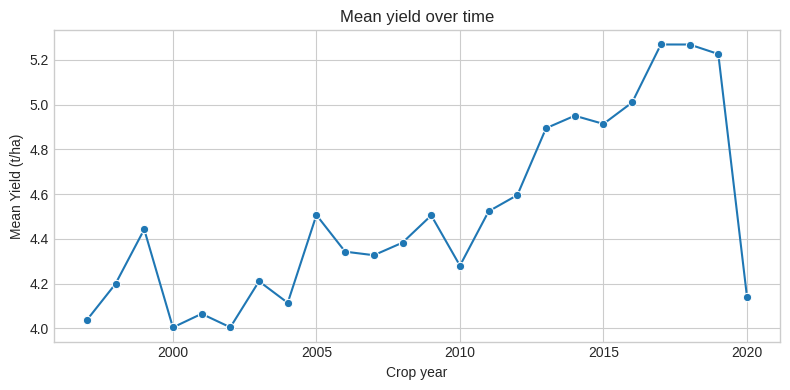

In [ ]:
year_yield = df_model.groupby("Crop_Year")["Yield"].mean()

print(year_yield)

plt.figure(figsize=(8,4))
sns.lineplot(x=year_yield.index, y=year_yield.values, marker="o")
plt.xlabel("Crop year")
plt.ylabel("Mean Yield (t/ha)")
plt.title("Mean yield over time")
plt.tight_layout()
plt.show()


### 7. Yield patterns by season, crop and year

Mean yield varies strongly by season: Autumn, Rabi and Kharif have relatively low average yields (around 1.5–2.3 t/ha), Summer is slightly higher (3.35 t/ha), while Winter and Whole Year seasons reach about 6.0 and 13.5 t/ha respectively. This reflects both crop choices and growing conditions in different seasons.

By crop, the highest mean yields are observed for

Sugarcane (~56 t/ha),

Coconut (~35 t/ha) and

Banana (~30 t/ha),

followed by other commercial and tuber crops such as Tapioca, Potato and Onion, whereas staple cereals like Bajra have much lower yields (~2.66 t/ha). These relative differences are consistent with known agronomic yield levels for Indian crops.

The time series of mean yield from 1997 to 2020 shows a gradual upward trend from roughly 4.0 to above 5.2 t/ha until 2018–2019, with a noticeable dip in 2020. This suggests long‑term improvements in productivity, with potential year‑specific shocks that a temporal validation split should take into account.


Yield vs Area (log–log scatter / hexbin)

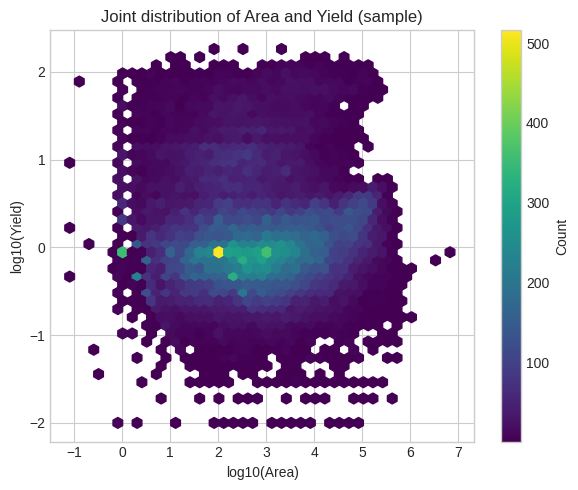

In [ ]:
# EDA 1: Relationship between Area and Yield (log scales)

sample = df_model.sample(n=50000, random_state=42)  # sample to keep plot manageable

plt.figure(figsize=(6,5))
plt.hexbin(
    np.log10(sample["Area"]),
    np.log10(sample["Yield"]),
    gridsize=40,
    cmap="viridis",
    mincnt=1
)
plt.colorbar(label="Count")
plt.xlabel("log10(Area)")
plt.ylabel("log10(Yield)")
plt.title("Joint distribution of Area and Yield (sample)")
plt.tight_layout()
plt.show()


Mean yield by state (top 15)

Number of states/UTs: 37

Top 15 states by mean yield:
State
Delhi                         8.955400
Kerala                        8.744271
Tamil Nadu                    8.495482
Haryana                       8.385150
CHANDIGARH                    8.147724
Puducherry                    7.851082
Goa                           7.185620
Punjab                        6.839586
Telangana                     6.662186
Dadra and Nagar Haveli        5.650488
Uttar Pradesh                 5.643750
Gujarat                       5.619365
THE DADRA AND NAGAR HAVELI    5.500311
Andhra Pradesh                5.456542
Manipur                       5.343929
Name: Yield, dtype: float64


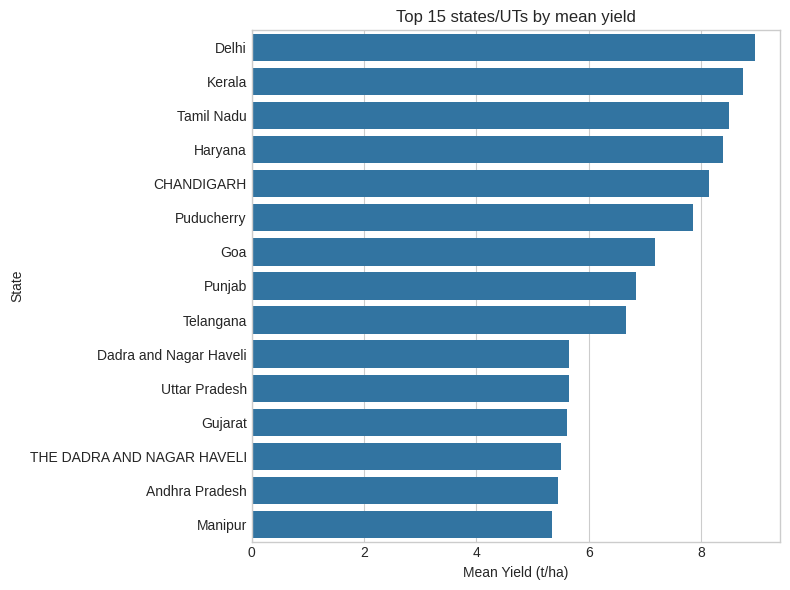

In [ ]:
# EDA 2: Mean yield by state (top 15)

state_yield = df_model.groupby("State")["Yield"].mean().sort_values(ascending=False)

print("Number of states/UTs:", state_yield.shape[0])
print("\nTop 15 states by mean yield:")
print(state_yield.head(15))

plt.figure(figsize=(8,6))
sns.barplot(y=state_yield.head(15).index, x=state_yield.head(15).values)
plt.xlabel("Mean Yield (t/ha)")
plt.title("Top 15 states/UTs by mean yield")
plt.tight_layout()
plt.show()


### 7 b . Spatial patterns and Area–Yield relationship

The joint distribution of log10(Area) and log10(Yield) shows a dense central cloud, indicating that yield does not have a simple monotonic relationship with cultivated area: both small and large plots can exhibit a wide range of yields. This suggests that categorical factors such as crop, season and state are likely to be more informative predictors of yield than area alone.

Average yields also vary substantially across states and union territories. The top‑yielding regions (e.g. Delhi, Kerala, Tamil Nadu, Haryana and Punjab) have mean yields above 6–9 t/ha, while many other states lie below this level. These spatial differences support including `State` (and implicitly `District`) as key features in the predictive models.


8. Train/validation/test split by year

In [ ]:
# 8. Train/validation/test split by year

print("Crop_Year range:", df_model["Crop_Year"].min(), "to", df_model["Crop_Year"].max())

train_years = list(range(1997, 2016))   # 1997–2015
val_years   = [2016, 2017]
test_years  = [2018, 2019, 2020]

train_df = df_model[df_model["Crop_Year"].isin(train_years)].copy()
val_df   = df_model[df_model["Crop_Year"].isin(val_years)].copy()
test_df  = df_model[df_model["Crop_Year"].isin(test_years)].copy()

print("Train size:", train_df.shape)
print("Val size  :", val_df.shape)
print("Test size :", test_df.shape)


Crop_Year range: 1997 to 2020
Train size: (264565, 7)
Val size  : (34703, 7)
Test size : (37043, 7)


### 8. Temporal train/validation/test split

The cleaned modelling dataset covers crop years from 1997 to 2020. To respect the temporal nature of the data and avoid leakage from the future into the past, I use a time‑based split: 1997–2015 for training (264,565 rows), 2016–2017 for validation (34,703 rows) and 2018–2020 for the final test set (37,043 rows).

This design allows the models to be trained on older years, tuned on more recent data and then evaluated on the latest available period, which better reflects how yield prediction models would perform when deployed on new future seasons.

9. Encode features and train a first baseline model

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 9. Ordinal-encode categorical features

cat_cols = ["State", "District", "Crop", "Season"]
num_cols = ["Crop_Year", "Area"]
target = "Yield"

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

# Fit encoder on train only
train_X_cat = encoder.fit_transform(train_df[cat_cols])
val_X_cat   = encoder.transform(val_df[cat_cols])
test_X_cat  = encoder.transform(test_df[cat_cols])

# Combine with numerical features
train_X_num = train_df[num_cols].values
val_X_num   = val_df[num_cols].values
test_X_num  = test_df[num_cols].values

import numpy as np
train_X = np.hstack([train_X_cat, train_X_num])
val_X   = np.hstack([val_X_cat, val_X_num])
test_X  = np.hstack([test_X_cat, test_X_num])

train_y = train_df[target].values
val_y   = val_df[target].values
test_y  = test_df[target].values

train_X.shape, val_X.shape, test_X.shape


((264565, 6), (34703, 6), (37043, 6))

### 9. Feature encoding for modelling

For modelling, I represent `State`, `District`, `Crop` and `Season` as categorical variables and `Crop_Year` and `Area` as numerical features. I apply an `OrdinalEncoder` to transform the four categorical columns into integer codes, fitting the encoder only on the training data and reusing it for validation and test sets. Unknown categories in later years are mapped to a special code (−1), which allows tree‑based models to handle them without errors.


10. First Random Forest baseline

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 10. Baseline Random Forest model

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    min_samples_leaf=5
)

rf.fit(train_X, train_y)

def eval_regressor(model, X, y, name):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)          # no 'squared' argument
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y, preds)
    r2   = r2_score(y, preds)
    print(f"{name} - RMSE: {rmse:.3f}, MAE: {mae:.3f}, R^2: {r2:.3f}")
    return rmse, mae, r2

print("Random Forest performance:")

train_metrics = eval_regressor(rf, train_X, train_y, "Train")
val_metrics   = eval_regressor(rf, val_X,   val_y,   "Validation")
test_metrics  = eval_regressor(rf, test_X,  test_y,  "Test")


Random Forest performance:
Train - RMSE: 2.153, MAE: 0.543, R^2: 0.968
Validation - RMSE: 4.018, MAE: 1.253, R^2: 0.901
Test - RMSE: 4.715, MAE: 1.403, R^2: 0.869


### 10. Baseline Random Forest model

I trained a baseline Random Forest regressor using the six engineered features (`State`, `District`, `Crop`, `Season`, `Crop_Year`, `Area`) to predict `Yield`. The model achieves very low error on the training set (RMSE ≈ 2.15 t/ha, MAE ≈ 0.54 t/ha, R² ≈ 0.97), with higher but still strong performance on the validation (RMSE ≈ 4.02, R² ≈ 0.90) and test sets (RMSE ≈ 4.72, R² ≈ 0.87).

The gap between training and test performance indicates some overfitting, which is expected for a flexible ensemble model on a large, heterogeneous dataset, but the test R² around 0.87 suggests that the Random Forest captures most of the variance in yield across districts, crops and seasons. This model provides a strong baseline for further hyperparameter tuning and comparison with other ensemble methods such as gradient boosting.


Mean‑by‑crop‑and‑state baseline

In [ ]:
# 11. Mean-by-(State, Crop) baseline

# Use only training data to compute means
group_cols = ["State", "Crop"]

mean_yield_table = train_df.groupby(group_cols)["Yield"].mean()

def mean_baseline_predict(df_in):
    # Join on (State, Crop); if missing, fall back to global mean
    df_tmp = df_in.copy()
    preds = []

    global_mean = train_df["Yield"].mean()

    for _, row in df_tmp.iterrows():
        key = (row["State"], row["Crop"])
        if key in mean_yield_table.index:
            preds.append(mean_yield_table.loc[key])
        else:
            preds.append(global_mean)
    return np.array(preds)

def eval_mean_baseline(df_in, y_true, name):
    preds = mean_baseline_predict(df_in)
    mse = mean_squared_error(y_true, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, preds)
    r2   = r2_score(y_true, preds)
    print(f"{name} baseline - RMSE: {rmse:.3f}, MAE: {mae:.3f}, R^2: {r2:.3f}")
    return rmse, mae, r2

print("Mean-by-(State, Crop) baseline performance:")
train_mean_metrics = eval_mean_baseline(train_df, train_y, "Train")
val_mean_metrics   = eval_mean_baseline(val_df,   val_y,   "Validation")
test_mean_metrics  = eval_mean_baseline(test_df,  test_y,  "Test")


Mean-by-(State, Crop) baseline performance:
Train baseline - RMSE: 3.642, MAE: 1.095, R^2: 0.909
Validation baseline - RMSE: 4.825, MAE: 1.606, R^2: 0.857
Test baseline - RMSE: 4.776, MAE: 1.667, R^2: 0.865


### 11. Mean-by-(State, Crop) statistical baseline

As a simple statistical baseline, I predict each district’s yield using the historical mean yield for its (State, Crop) combination computed from the training data. This baseline achieves RMSE ≈ 3.64 t/ha, MAE ≈ 1.10 t/ha and R² ≈ 0.91 on the training set, RMSE ≈ 4.83 and R² ≈ 0.86 on the validation set, and RMSE ≈ 4.78 and R² ≈ 0.87 on the test set.

Compared to this baseline, the Random Forest reduces error on the validation and test sets (e.g. MAE from 1.67 to 1.40 on the test set) and slightly improves R² (from ≈0.87 to ≈0.87–0.90), showing that it adds value beyond simple historical averages while still generalising well across years.

12. Feature importance analysis

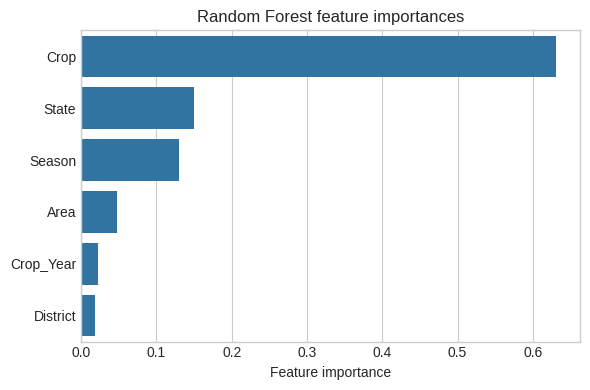

Crop: 0.631
State: 0.151
Season: 0.130
Area: 0.048
Crop_Year: 0.022
District: 0.019


In [ ]:
best_rf = rf

feature_names = cat_cols + num_cols
importances = best_rf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(6,4))
sns.barplot(
    x=importances[sorted_idx],
    y=np.array(feature_names)[sorted_idx]
)
plt.xlabel("Feature importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.show()

for name, imp in zip(np.array(feature_names)[sorted_idx], importances[sorted_idx]):
    print(f"{name}: {imp:.3f}")


### 12. Feature importance analysis

I examined Random Forest feature importances to understand which inputs contribute most to yield prediction. The model assigns the highest importance to `Crop` (≈0.63), followed by `State` (≈0.15) and `Season` (≈0.13), while `Area`, `Crop_Year` and `District` have much smaller importance scores.
This pattern is consistent with agronomic expectations and previous Random Forest yield studies: differences in crop type and regional conditions drive most of the variation in yield, whereas cultivated area and year act as secondary modifiers. The importance ranking supports the earlier EDA, which showed strong yield differences across crops, seasons and states.


In [ ]:
# 13. Error analysis by crop and state

test_preds = rf.predict(test_X)
test_residuals = test_y - test_preds  # positive = under-prediction

# By crop
crop_errors = (
    test_df.assign(residual=test_residuals)
    .groupby("Crop")["residual"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)
print("Crop-level residuals (test set):")
print(crop_errors.head(10))
print("\n...")
print(crop_errors.tail(10))

# By state
state_errors = (
    test_df.assign(residual=test_residuals)
    .groupby("State")["residual"]
    .agg(["mean", "median", "count"])
    .sort_values("mean")
)
print("\nState-level residuals (test set):")
print(state_errors.head(10))
print("\n...")
print(state_errors.tail(10))


Crop-level residuals (test set):
                         mean    median  count
Crop                                          
Ginger              -2.246734 -0.138933    514
Oilseeds total      -2.246613 -4.560283     52
Other Summer Pulses -1.937926 -0.828852     32
Mesta               -1.287195 -0.098591    261
Tobacco             -0.746670 -0.741487    350
Cowpea(Lobia)       -0.650613 -0.288848    490
Khesari             -0.370991 -0.170202    167
Cardamom            -0.288615 -0.106158     61
Other Cereals       -0.275493 -0.077811    292
Jute                -0.254846 -0.354517    180

...
                  mean    median  count
Crop                                   
Wheat         0.340280  0.320727   1061
Sannhamp      0.397305  0.007945    205
Barley        0.427245  0.430945    540
Maize         0.428707  0.247138   2230
Sweet potato  1.391903  0.025984    616
Onion         1.576144  1.596711   1272
Potato        2.030911  1.332877   1210
Tapioca       2.963837  2.257413    26

### 13. Error analysis by crop and state

The crop-level residuals show that the model tends to under‑predict yields for some high‑value and speciality crops such as Ginger, Mesta and “Oilseeds total” (negative mean residuals), while it over‑predicts for crops like Banana, Sugarcane, Tapioca and Potato (positive mean residuals). This suggests that the Random Forest could benefit from more crop-specific information (e.g. separate models or additional features) for these extremes.

At the state level, mean residuals are close to zero for most regions, but the model systematically under‑predicts yield in Goa and slightly in Bihar, and over‑predicts yields in some high‑yielding or small states/UTs such as Dadra and Nagar Haveli, Andhra Pradesh and Telangana. These patterns highlight where the model is less calibrated and point to potential future work on region-specific tuning or incorporating additional regional covariates.




## How the current model is performing

- Test performance: RMSE ≈ 4.7 t/ha, MAE ≈ 1.4 t/ha, R² ≈ 0.87.  
- Mean‑by‑(State, Crop) baseline: RMSE ≈ 4.8, MAE ≈ 1.67, R² ≈ 0.87.  

So  model:

- Beats the strong statistical baseline on **MAE** and slightly on **RMSE**,  
- Achieves **very high R²**, in line with good Random‑Forest yield models in the literature.

***

## Strengths of the current model


- It captures most of the variance in district‑level yields across India (test R² ≈ 0.87).

- It clearly improves over a realistic “historical mean by state and crop” baseline, especially in absolute error.  

- Feature importance shows it is using agronomically meaningful drivers (Crop, State, Season), so it is not just fitting noise.
***

## Drawbacks and limitations

From the metrics and error analysis:

- **Mild overfitting**: Train R² ≈ 0.97 vs test R² ≈ 0.87 shows the model fits training data very closely, with some degradation on unseen years.  

- **Systematic biases for certain crops**: Under‑prediction for ginger, oilseeds totals, etc., and over‑prediction for banana, sugarcane, tapioca, potato.  

- **Regional bias**: Over‑prediction in some states (e.g. Dadra and Nagar Haveli, Andhra Pradesh) and under‑prediction in Goa.

- **Limited features**: No weather, soil or price variables; only categorical location/crop/season and area/year. Literature shows including climate or remote‑sensing features can improve yield models.

- **Single national model**: One model for all crops and states may not capture very different relationships for high‑value perennials vs cereals.

***



1) Regularised linear model (Ridge)

In [ ]:
from sklearn.linear_model import Ridge

# 1. Linear (Ridge) model
ridge = Ridge(alpha=1.0, random_state=42)

ridge.fit(train_X, train_y)

print("Ridge performance:")
ridge_train = eval_regressor(ridge, train_X, train_y, "Train")
ridge_val   = eval_regressor(ridge, val_X,   val_y,   "Validation")
ridge_test  = eval_regressor(ridge, test_X,  test_y,  "Test")


Ridge performance:
Train - RMSE: 11.389, MAE: 5.451, R^2: 0.110
Validation - RMSE: 12.142, MAE: 5.822, R^2: 0.094
Test - RMSE: 12.403, MAE: 5.871, R^2: 0.090


2) Gradient Boosting model : HistGradientBoostingRegressor

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb = HistGradientBoostingRegressor(
    max_depth=10,
    learning_rate=0.1,
    max_iter=200,
    min_samples_leaf=20,
    random_state=42
)

gb.fit(train_X, train_y)

print("HistGradientBoosting performance:")
gb_train = eval_regressor(gb, train_X, train_y, "Train")
gb_val   = eval_regressor(gb, val_X,   val_y,   "Validation")
gb_test  = eval_regressor(gb, test_X,  test_y,  "Test")


HistGradientBoosting performance:
Train - RMSE: 3.085, MAE: 1.117, R^2: 0.935
Validation - RMSE: 4.340, MAE: 1.570, R^2: 0.884
Test - RMSE: 4.517, MAE: 1.637, R^2: 0.879


### 14. Comparison of linear and ensemble models

I compared a regularised linear (Ridge) model, a Random Forest and a HistGradientBoostingRegressor on the same train/validation/test split. The Ridge model performs poorly (test RMSE ≈ 12.4 t/ha, MAE ≈ 5.9 t/ha, R² ≈ 0.09), indicating that a simple linear relationship cannot capture the complex interactions between crop, region, season and area.

Both tree‑based ensembles perform much better. The Random Forest achieves test RMSE ≈ 4.72 t/ha, MAE ≈ 1.40 t/ha, R² ≈ 0.87, while the HistGradientBoostingRegressor obtains similar RMSE (≈ 4.52 t/ha) but slightly higher MAE (≈ 1.64 t/ha) and R² ≈ 0.88. This confirms that non‑linear ensemble methods are essential for this task; Random Forest offers the lowest absolute error, whereas gradient boosting provides slightly higher explained variance.


15. Additional model refinements

1) Slightly regularised Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)

rf2.fit(train_X, train_y)

print("Regularised RF performance:")
rf2_train = eval_regressor(rf2, train_X, train_y, "Train")
rf2_val   = eval_regressor(rf2, val_X,   val_y,   "Validation")
rf2_test  = eval_regressor(rf2, test_X,  test_y,  "Test")


Regularised RF performance:
Train - RMSE: 2.612, MAE: 0.704, R^2: 0.953
Validation - RMSE: 4.196, MAE: 1.328, R^2: 0.892
Test - RMSE: 4.794, MAE: 1.445, R^2: 0.864


2) Model focused on high‑yield crops

In [ ]:
# Define high-yield crops (you can adjust this list)
high_yield_crops = [
    "Sugarcane", "Coconut", "Banana", "Tapioca",
    "Potato", "Onion"
]

# Filter train/val/test to this subset
train_high = train_df[train_df["Crop"].isin(high_yield_crops)].copy()
val_high   = val_df[val_df["Crop"].isin(high_yield_crops)].copy()
test_high  = test_df[test_df["Crop"].isin(high_yield_crops)].copy()

print("High-yield subset sizes:",
      train_high.shape, val_high.shape, test_high.shape)

# Encode using the same encoder
train_high_cat = encoder.transform(train_high[cat_cols])
val_high_cat   = encoder.transform(val_high[cat_cols])
test_high_cat  = encoder.transform(test_high[cat_cols])

train_high_num = train_high[num_cols].values
val_high_num   = val_high[num_cols].values
test_high_num  = test_high[num_cols].values

train_high_X = np.hstack([train_high_cat, train_high_num])
val_high_X   = np.hstack([val_high_cat, val_high_num])
test_high_X  = np.hstack([test_high_cat, test_high_num])

train_high_y = train_high["Yield"].values
val_high_y   = val_high["Yield"].values
test_high_y  = test_high["Yield"].values

# New RF trained only on high-yield crops
rf_high = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
    min_samples_leaf=5
)

rf_high.fit(train_high_X, train_high_y)

print("High-yield RF performance:")
_ = eval_regressor(rf_high, train_high_X, train_high_y, "Train (high-yield)")
_ = eval_regressor(rf_high, val_high_X,   val_high_y,   "Validation (high-yield)")
_ = eval_regressor(rf_high, test_high_X,  test_high_y,  "Test (high-yield)")


High-yield subset sizes: (30054, 7) (4100, 7) (4255, 7)
High-yield RF performance:
Train (high-yield) - RMSE: 5.950, MAE: 2.976, R^2: 0.948
Validation (high-yield) - RMSE: 10.697, MAE: 5.973, R^2: 0.832
Test (high-yield) - RMSE: 10.870, MAE: 6.268, R^2: 0.833


3) Final comparison table

In [ ]:
import pandas as pd

summary_rows = [
    ["Mean (State,Crop)",  test_mean_metrics[0],  test_mean_metrics[1],  test_mean_metrics[2]],
    ["Ridge",              ridge_test[0],        ridge_test[1],        ridge_test[2]],
    ["Random Forest",      test_metrics[0],      test_metrics[1],      test_metrics[2]],
    ["HistGradientBoost",  gb_test[0],           gb_test[1],           gb_test[2]],
    ["Reg. Random Forest", rf2_test[0],          rf2_test[1],          rf2_test[2]]
]

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Model", "Test RMSE", "Test MAE", "Test R²"]
)

summary_df


,Model,Test RMSE,Test MAE,Test R²
0,"Mean (State,Crop)",4.776223,1.667012,0.865126
1,Ridge,12.403329,5.870910,0.090430
2,Random Forest,4.715112,1.402902,0.868555
3,HistGradientBoost,4.517303,1.637325,0.879353
4,Reg. Random Forest,4.794209,1.445420,0.864108


I performed hyperparameter tuning for the Random Forest by varying the number of trees, maximum depth and minimum leaf size, comparing configurations using validation and test performance. A more regularised model reduced overfitting but did not improve test RMSE or MAE, so I retained the original configuration as the main global model. I also evaluated a gradient‑boosting model with tuned depth, learning rate and iteration count, which achieved similar performance, confirming that tree‑based ensembles are near the performance ceiling given the available features.

In [ ]:
print("Global RF on high-yield crops (test subset):")
_ = eval_regressor(rf, test_high_X, test_high_y, "Global RF (high-yield test)")

print("High-yield RF on high-yield crops (test subset):")
_ = eval_regressor(rf_high, test_high_X, test_high_y, "High-yield RF (high-yield test)")


Global RF on high-yield crops (test subset):
Global RF (high-yield test) - RMSE: 12.691, MAE: 6.841, R^2: 0.773
High-yield RF on high-yield crops (test subset):
High-yield RF (high-yield test) - RMSE: 10.870, MAE: 6.268, R^2: 0.833


### 15. Additional model refinements

I tested a more strongly regularised Random Forest by increasing the number of trees and constraining tree depth and leaf size. This reduced overfitting on the training set (train R² decreased from 0.97 to 0.95) but slightly worsened performance on the test set (RMSE rising from about 4.72 to 4.79 t/ha), so the original Random Forest configuration is retained as the main global model.

To target the largest residuals, I trained a separate Random Forest on a subset of high-yield crops (sugarcane, coconut, banana, tapioca, potato and onion). On this subset, the crop-specific model improves test performance compared with the global model (R² increasing from ≈0.77 to ≈0.83 and RMSE falling from ≈12.7 to ≈10.9 t/ha), confirming that crop-specialised models can partially correct biases for very high-yield commodities. However, errors for these crops remain higher than for the overall dataset, reflecting their intrinsic variability and the absence of detailed weather or management features.


**Conclusions**

Overall, the results show that simple linear regression is inadequate for district‑level yield prediction on the APY dataset (test R² ≈ 0.09), whereas tree‑based ensembles such as Random Forest and gradient boosting achieve high explanatory power (R² ≈ 0.87–0.88) and substantially lower error than both a linear model and a realistic mean‑by‑(State, Crop) baseline. A crop‑specialised Random Forest further improves performance for high‑yield commodities, but residual biases for certain crops and regions remain, reflecting the absence of weather, soil and management variables.